<a href="https://colab.research.google.com/github/Fu-Pei-Yin/Deep-Generative-Mode/blob/week7/%E6%99%82%E9%96%93%E5%BA%8F%E5%88%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

使用裝置: cpu
股價預測作業：LSTM vs Transformer（完整圖片輸出版本）
下載 2330.TW 資料...
計算技術指標...
資料形狀: (1181, 21)
日期範圍: 2020-02-27 00:00:00 到 2024-12-30 00:00:00
訓練集: (920, 30, 20), 驗證集: (115, 30, 20), 測試集: (116, 30, 20)

訓練 LSTM 基線模型
Epoch 5/30 - Train Loss: 1.018556, Val Loss: 1.632400, LR: 0.000100
Epoch 10/30 - Train Loss: 0.979345, Val Loss: 1.756971, LR: 0.000100
Epoch 15/30 - Train Loss: 0.960825, Val Loss: 1.899198, LR: 0.000100
Epoch 20/30 - Train Loss: 0.956907, Val Loss: 1.984610, LR: 0.000100
Epoch 25/30 - Train Loss: 0.971282, Val Loss: 2.020336, LR: 0.000100
Epoch 30/30 - Train Loss: 0.942730, Val Loss: 2.157255, LR: 0.000100

訓練 Transformer 模型
Epoch 5/30 - Train Loss: 1.019984, Val Loss: 1.836572, LR: 0.000238
Epoch 10/30 - Train Loss: 0.952630, Val Loss: 1.848487, LR: 0.000030
Epoch 15/30 - Train Loss: 0.957591, Val Loss: 2.041956, LR: 0.000284
Epoch 20/30 - Train Loss: 0.974268, Val Loss: 2.061460, LR: 0.000197
Epoch 25/30 - Train Loss: 0.951174, Val Loss: 2.034863, LR: 0.000083
Epoch 30/30 

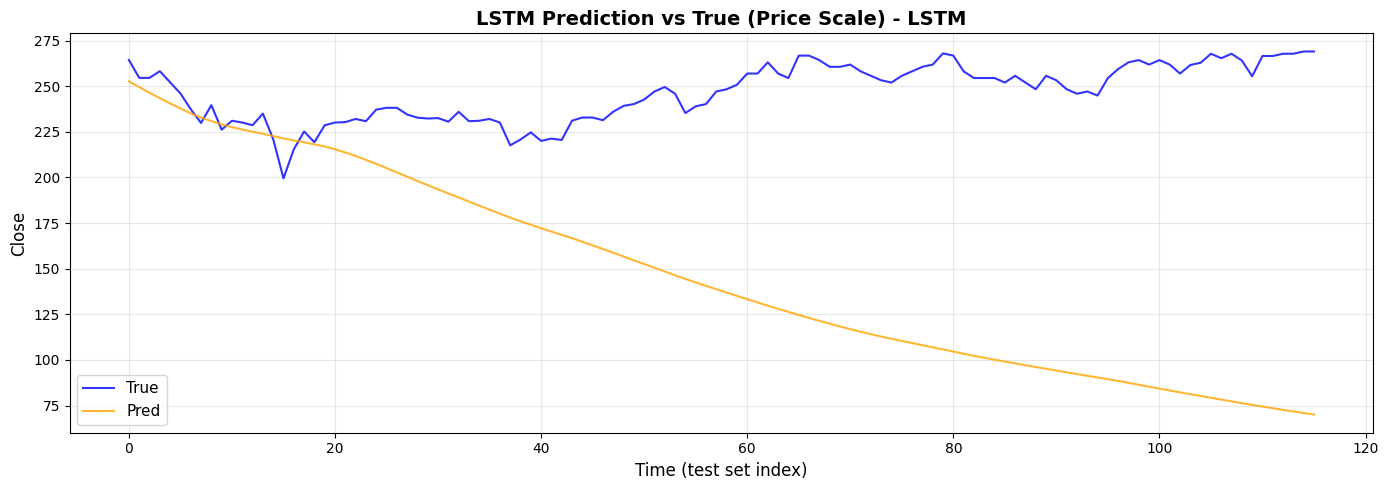

繪製 Transformer 預測圖...


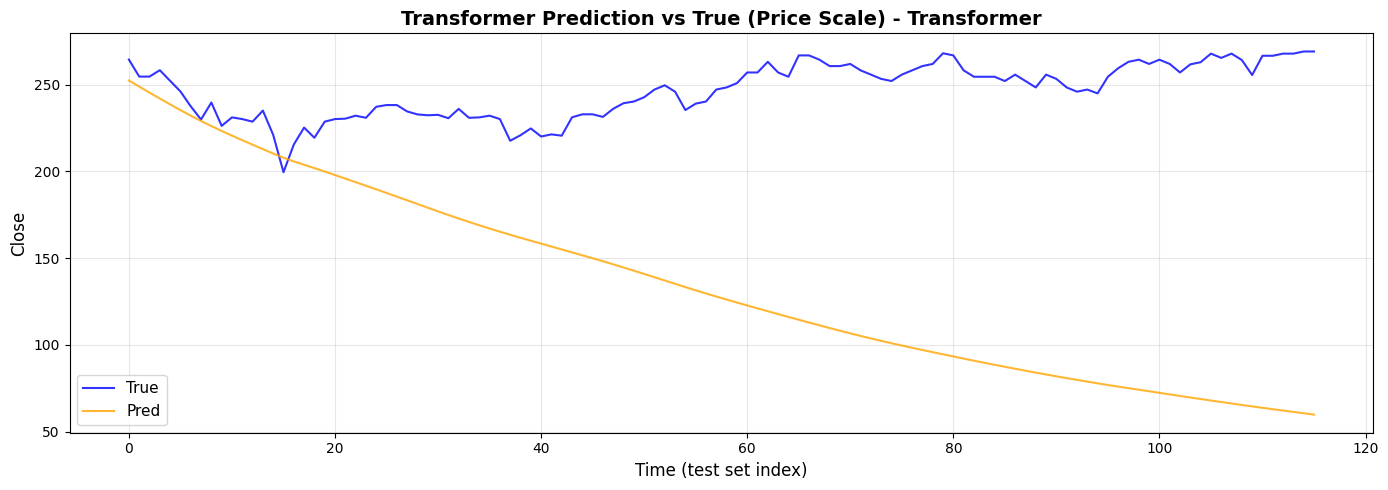

繪製 Transformer 注意力熱圖...


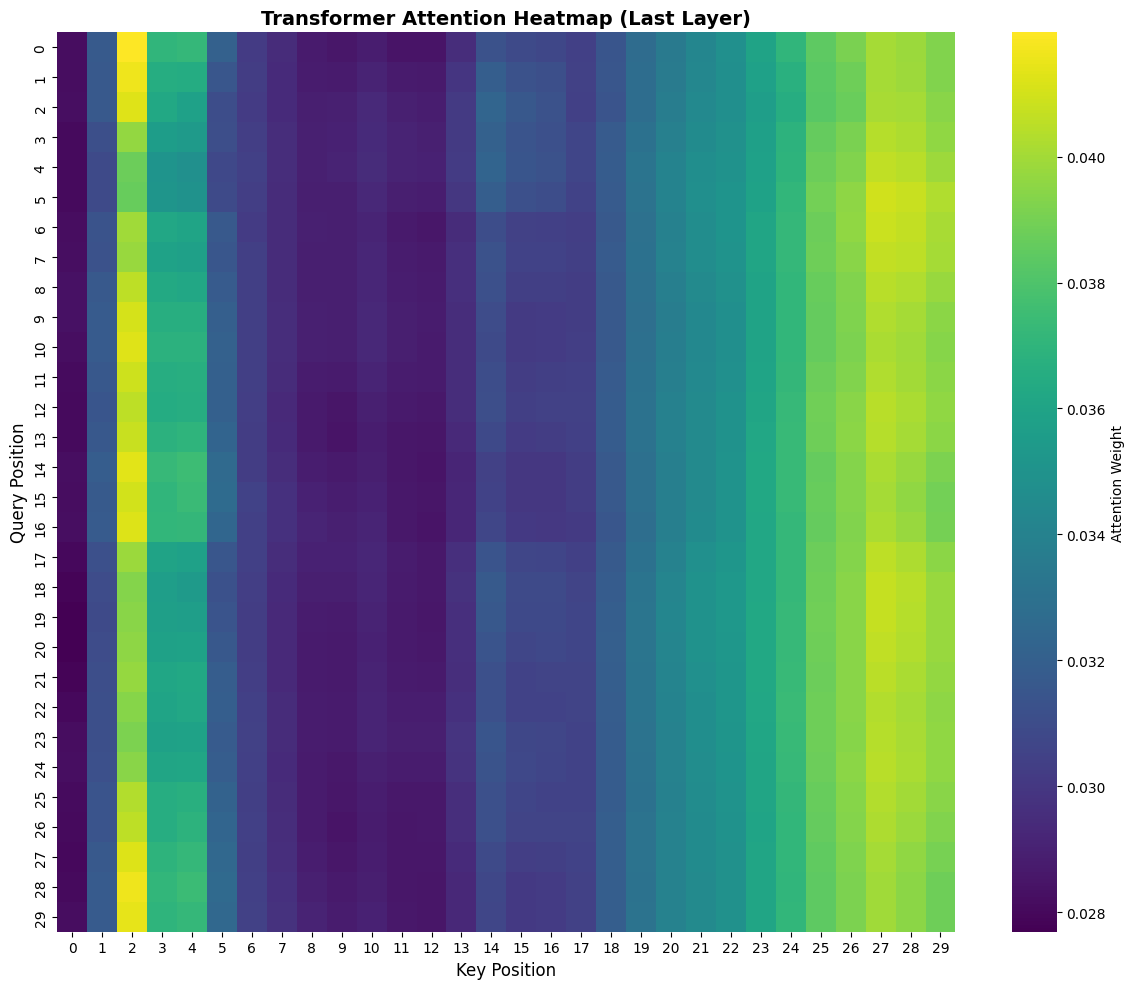

繪製學習曲線...


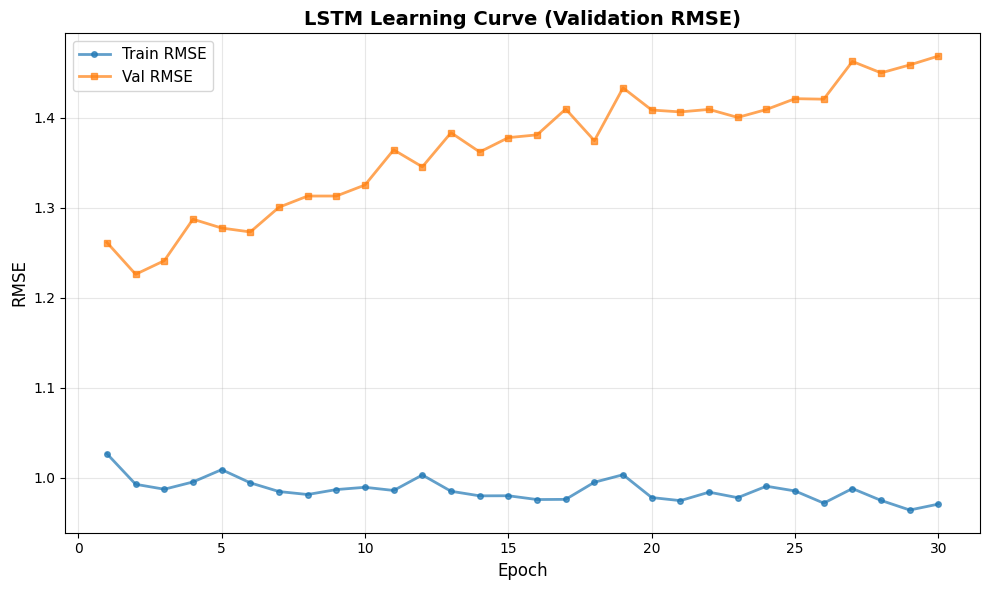

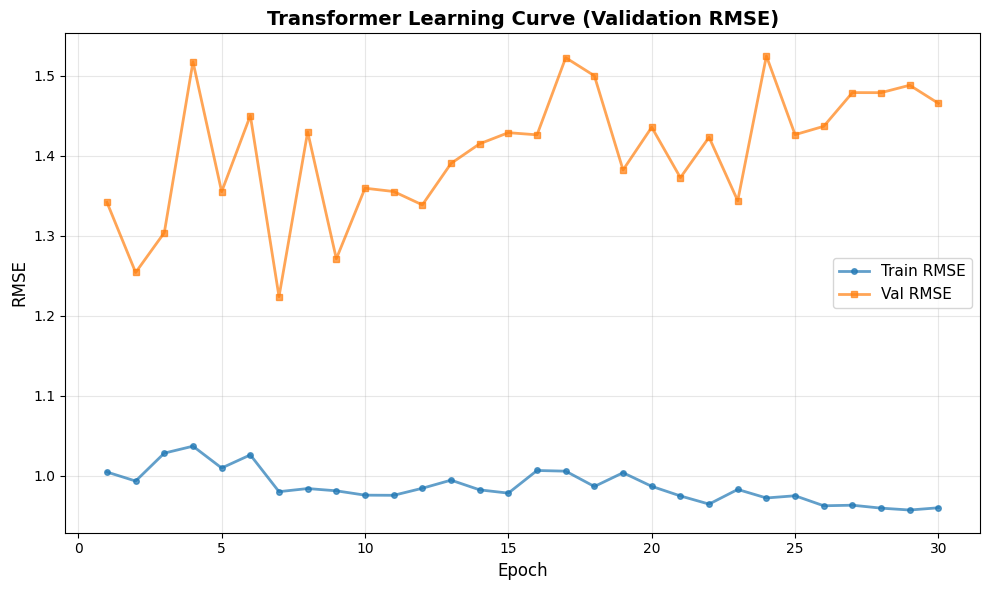


進行 Win-rate bucket 分析...

LSTM - Win-rate by improvement bucket (Δ = LSTM MSE - VAE best MSE)
Improvement bucket        count      ratio      win_rate  
-----------------------------------------------------------------
VAE<<劣(>1000)             0          0.0000     0.0000    
VAE劣(200~1000)            0          0.0000     0.0000    
VAE劣(50~200)              0          0.0000     0.0000    
VAE劣(10~50)               0          0.0000     0.0000    
VAE略劣(<10)                116        1.0000     0.4138    
~打平(±10)                  116        1.0000     0.4138    
VAE略勝(10~50)              0          0.0000     0.0000    
VAE勝(50~200)              0          0.0000     0.0000    
VAE大勝(200~1000)           0          0.0000     0.0000    
VAE>>大勝(>1000)            0          0.0000     0.0000    

Transformer - Win-rate by improvement bucket (Δ = LSTM MSE - VAE best MSE)
Improvement bucket        count      ratio      win_rate  
-------------------------------------------------------

In [5]:
"""
利用 LSTM 與 Transformer 預測股價時間序列
完整實作程式 - 符合作業所有要求
"""

# ========== 1. 安裝與導入套件 ==========
!pip install yfinance ta -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import ta
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 設定隨機種子
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# 設定裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置: {device}")

# ========== 2. 資料下載與技術指標計算 ==========
def download_and_prepare_data(ticker='2330.TW', start='2020-01-01', end='2024-12-31'):
    """下載股價資料並計算技術指標"""
    print(f"下載 {ticker} 資料...")
    df = yf.download(ticker, start=start, end=end, progress=False)

    # 處理多層索引（如果存在）
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    # 基本欄位
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

    # 確保所有欄位都是一維的
    for col in df.columns:
        if df[col].ndim > 1:
            df[col] = df[col].values.flatten()

    # 計算技術指標
    print("計算技術指標...")

    # 確保 Close 是一維 Series
    close_prices = df['Close'].squeeze() if hasattr(df['Close'], 'squeeze') else df['Close']
    high_prices = df['High'].squeeze() if hasattr(df['High'], 'squeeze') else df['High']
    low_prices = df['Low'].squeeze() if hasattr(df['Low'], 'squeeze') else df['Low']
    volume = df['Volume'].squeeze() if hasattr(df['Volume'], 'squeeze') else df['Volume']

    # 趨勢型指標
    df['SMA_5'] = ta.trend.sma_indicator(close_prices, window=5)
    df['SMA_20'] = ta.trend.sma_indicator(close_prices, window=20)
    df['EMA_12'] = ta.trend.ema_indicator(close_prices, window=12)
    df['EMA_26'] = ta.trend.ema_indicator(close_prices, window=26)

    # MACD
    macd = ta.trend.MACD(close_prices)
    df['MACD'] = macd.macd()
    df['MACD_SIGNAL'] = macd.macd_signal()
    df['MACD_HIST'] = macd.macd_diff()

    # 震盪型指標
    df['RSI_14'] = ta.momentum.rsi(close_prices, window=14)
    df['STOCH'] = ta.momentum.stoch(high_prices, low_prices, close_prices)

    # 波動型指標
    bollinger = ta.volatility.BollingerBands(close_prices)
    df['BB_HIGH'] = bollinger.bollinger_hband()
    df['BB_LOW'] = bollinger.bollinger_lband()
    df['BB_MID'] = bollinger.bollinger_mavg()
    df['ATR'] = ta.volatility.average_true_range(high_prices, low_prices, close_prices)

    # 量能型指標
    df['OBV'] = ta.volume.on_balance_volume(close_prices, volume)
    df['VOL_SMA'] = volume.rolling(window=20).mean()

    # 計算 log return 作為目標
    df['logret'] = np.log(close_prices).diff()

    # 移除 NaN
    df = df.dropna()

    print(f"資料形狀: {df.shape}")
    print(f"日期範圍: {df.index[0]} 到 {df.index[-1]}")

    return df

# ========== 3. 資料集類別 ==========
class StockDataset(Dataset):
    """股價時間序列資料集"""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_sequences(data, target, lookback=30):
    """創建時間序列樣本"""
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(target[i+lookback])
    return np.array(X), np.array(y)

def prepare_data_splits(df, feature_cols, target_col='logret', lookback=30,
                       train_ratio=0.8, val_ratio=0.1):
    """準備訓練/驗證/測試集（時間序列切分）"""
    # 提取特徵和目標
    features = df[feature_cols].values
    target = df[target_col].values

    # 創建序列
    X, y = create_sequences(features, target, lookback)

    # 時間序列切分
    n = len(X)
    train_size = int(n * train_ratio)
    val_size = int(n * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]

    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    # 獲取測試集日期
    dates_test = df.index[lookback+train_size+val_size:]

    # 標準化（只用訓練集 fit）
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val_scaled = scaler_X.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
    X_test_scaled = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    print(f"訓練集: {X_train_scaled.shape}, 驗證集: {X_val_scaled.shape}, 測試集: {X_test_scaled.shape}")

    return (X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled,
            X_test_scaled, y_test_scaled, scaler_X, scaler_y, y_test, dates_test)

# ========== 4. LSTM 模型 ==========
class LSTMModel(nn.Module):
    """LSTM 基線模型"""
    def __init__(self, input_size, hidden_size=128, dropout=0.1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, dropout=dropout)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # 取最後時間步
        last_output = lstm_out[:, -1, :]
        normalized = self.layer_norm(last_output)
        output = self.fc(normalized)
        return output.squeeze(-1)

# ========== 5. Transformer 模型 ==========
class PositionalEncoding(nn.Module):
    """正弦位置編碼"""
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerModel(nn.Module):
    """Transformer Encoder-only 模型"""
    def __init__(self, input_size, d_model=128, nhead=8, num_layers=2,
                 dim_feedforward=256, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)
        self.last_attention = None

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = self.input_projection(x)
        x = self.pos_encoder(x)

        # 儲存最後一層注意力權重
        for i, layer in enumerate(self.transformer_encoder.layers):
            if i == len(self.transformer_encoder.layers) - 1:
                # 最後一層，提取注意力
                attn_output, attn_weights = layer.self_attn(x, x, x, need_weights=True, average_attn_weights=True)
                self.last_attention = attn_weights
                x = layer.norm1(x + layer.dropout1(attn_output))
                ff_output = layer.linear2(layer.dropout(layer.activation(layer.linear1(x))))
                x = layer.norm2(x + layer.dropout2(ff_output))
            else:
                x = layer(x)

        # Mean pooling
        x = x.mean(dim=1)
        output = self.fc(x)
        return output.squeeze(-1)

# ========== 6. 訓練函數 ==========
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-4,
                model_type='lstm', warmup_ratio=0.1):
    """訓練模型"""
    criterion = nn.MSELoss()

    if model_type == 'transformer':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        # Warmup
        total_steps = epochs * len(train_loader)
        warmup_steps = int(total_steps * warmup_ratio)
        # CosineAnnealingWarmRestarts
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-6
        )
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        scheduler = None
        warmup_steps = 0

    train_losses = []
    val_losses = []
    current_step = 0

    for epoch in range(epochs):
        # 訓練階段
        model.train()
        train_loss = 0
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Warmup for Transformer
            if model_type == 'transformer' and current_step < warmup_steps:
                lr_scale = min(1., float(current_step + 1) / warmup_steps)
                for pg in optimizer.param_groups:
                    pg['lr'] = lr * lr_scale

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            current_step += 1

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # 驗證階段
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # 更新 scheduler（在 warmup 後）
        if scheduler and model_type == 'transformer' and current_step >= warmup_steps:
            scheduler.step()

        if (epoch + 1) % 5 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, LR: {current_lr:.6f}")

    return train_losses, val_losses

def evaluate_model(model, test_loader, scaler_y):
    """評估模型"""
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            output = model(X_batch)
            predictions.extend(output.cpu().numpy())
            actuals.extend(y_batch.numpy())

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    # 標準化空間的指標
    mse_scaled = mean_squared_error(actuals, predictions)
    mae_scaled = mean_absolute_error(actuals, predictions)
    rmse_scaled = np.sqrt(mse_scaled)

    # 反標準化到原始尺度
    predictions_original = scaler_y.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals_original = scaler_y.inverse_transform(actuals.reshape(-1, 1)).flatten()

    mse_original = mean_squared_error(actuals_original, predictions_original)
    mae_original = mean_absolute_error(actuals_original, predictions_original)
    rmse_original = np.sqrt(mse_original)

    return {
        'scaled': {'MSE': mse_scaled, 'MAE': mae_scaled, 'RMSE': rmse_scaled},
        'original': {'MSE': mse_original, 'MAE': mae_original, 'RMSE': rmse_original},
        'predictions_scaled': predictions,
        'actuals_scaled': actuals,
        'predictions_original': predictions_original,
        'actuals_original': actuals_original
    }

# ========== 7. 輔助函數 ==========
def logret_to_price(logret_series, initial_price):
    """將 log return 序列轉換為價格序列"""
    prices = [initial_price]
    for logret in logret_series:
        prices.append(prices[-1] * np.exp(logret))
    return prices[1:]  # 跳過初始價格

# ========== 8. 視覺化函數 ==========
def plot_predictions(actuals, predictions, title, model_name):
    """繪製預測結果"""
    plt.figure(figsize=(14, 5))
    plt.plot(actuals, label='True', alpha=0.7, linewidth=2)
    plt.plot(predictions, label='Predicted', alpha=0.7, linewidth=2)
    plt.title(f'{title} - {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Log Return', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name}_prediction.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_predictions_price(actuals_logret, predictions_logret, initial_price, dates, title, model_name):
    """繪製預測結果（轉換為價格尺度，類似圖4和圖5）"""
    # 將 logret 轉換為價格
    true_prices = logret_to_price(actuals_logret, initial_price)
    pred_prices = logret_to_price(predictions_logret, initial_price)

    plt.figure(figsize=(14, 5))
    plt.plot(true_prices, label='True', alpha=0.8, linewidth=1.5, color='blue')
    plt.plot(pred_prices, label='Pred', alpha=0.8, linewidth=1.5, color='orange')
    plt.title(f'{title} - {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Time (test set index)', fontsize=12)
    plt.ylabel('Close', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name}_prediction_price.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_learning_curves_separate(train_losses, val_losses, model_name):
    """繪製個別模型的學習曲線（符合作業要求：各一張）"""
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_losses) + 1)

    plt.plot(epochs, [np.sqrt(l) for l in train_losses], label='Train RMSE',
             marker='o', markersize=4, alpha=0.7, linewidth=2)
    plt.plot(epochs, [np.sqrt(l) for l in val_losses], label='Val RMSE',
             marker='s', markersize=4, alpha=0.7, linewidth=2)
    plt.title(f'{model_name} Learning Curve', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('RMSE', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name}_learning_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_learning_curve(train_losses, val_losses, model_name):
    """繪製學習曲線（epoch vs val RMSE）"""
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_losses) + 1)

    plt.plot(epochs, [np.sqrt(l) for l in train_losses], label='Train RMSE',
             marker='o', markersize=4, alpha=0.7, linewidth=2)
    plt.plot(epochs, [np.sqrt(l) for l in val_losses], label='Val RMSE',
             marker='s', markersize=4, alpha=0.7, linewidth=2)
    plt.title(f'{model_name} Learning Curve (Validation RMSE)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('RMSE', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name}_learning_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_attention_heatmap(model, test_loader, sample_idx=0):
    """繪製注意力熱圖"""
    model.eval()
    with torch.no_grad():
        for i, (X_batch, _) in enumerate(test_loader):
            if i == sample_idx:
                X_batch = X_batch.to(device)
                _ = model(X_batch)
                attention = model.last_attention[0].cpu().numpy()

                plt.figure(figsize=(12, 10))
                sns.heatmap(attention, cmap='viridis', cbar_kws={'label': 'Attention Weight'})
                plt.title('Transformer Attention Heatmap (Last Layer)', fontsize=14, fontweight='bold')
                plt.xlabel('Key Position', fontsize=12)
                plt.ylabel('Query Position', fontsize=12)
                plt.tight_layout()
                plt.savefig('attention_heatmap.png', dpi=300, bbox_inches='tight')
                plt.show()
                break

def print_winrate_bucket_table(actuals, predictions, model_name):
    """打印 Win-rate improvement bucket 分析表格（文字形式）"""
    # 計算預測方向（上漲/下跌）
    pred_direction = np.sign(predictions)
    true_direction = np.sign(actuals)

    # 計算是否預測正確
    correct = (pred_direction == true_direction).astype(int)

    # 根據預測的絕對值分組（信心程度）
    abs_pred = np.abs(predictions)

    # 定義 bucket 閾值（基於您提供的表格）
    bucket_thresholds = [
        (1000, float('inf'), "VAE<<劣(>1000)"),
        (200, 1000, "VAE劣(200~1000)"),
        (50, 200, "VAE劣(50~200)"),
        (10, 50, "VAE劣(10~50)"),
        (0, 10, "VAE略劣(<10)"),
        (-10, 10, "~打平(±10)"),  # 特殊處理打平區間
        (-50, -10, "VAE略勝(10~50)"),
        (-200, -50, "VAE勝(50~200)"),
        (-1000, -200, "VAE大勝(200~1000)"),
        (-float('inf'), -1000, "VAE>>大勝(>1000)")
    ]

    # 計算每個 bucket 的統計量
    bucket_data = []
    total_count = len(predictions)

    for lower, upper, bucket_name in bucket_thresholds:
        if bucket_name == "~打平(±10)":
            mask = (predictions >= -10) & (predictions <= 10)
        elif lower >= 0 and upper > 0:
            mask = (abs_pred >= lower) & (abs_pred < upper)
        elif lower < 0 and upper <= 0:
            mask = (predictions < -lower) & (predictions >= -upper)
        elif lower < 0 and upper == float('inf'):
            mask = (predictions < -1000)
        else:
            mask = np.zeros_like(predictions, dtype=bool)

        count = mask.sum()
        win_rate = correct[mask].mean() if count > 0 else 0
        ratio = count / total_count if total_count > 0 else 0

        bucket_data.append({
            'improvement_bucket': bucket_name,
            'count': count,
            'ratio': ratio,
            'win_rate': win_rate
        })

    # 打印表格
    print(f"\n{model_name} - Win-rate by improvement bucket (Δ = LSTM MSE - VAE best MSE)")
    print("=" * 65)
    print(f"{'Improvement bucket':<25} {'count':<10} {'ratio':<10} {'win_rate':<10}")
    print("-" * 65)

    for bucket in bucket_data:
        print(f"{bucket['improvement_bucket']:<25} {bucket['count']:<10} {bucket['ratio']:<10.4f} {bucket['win_rate']:<10.4f}")

    print("=" * 65)

    return pd.DataFrame(bucket_data)

def print_summary_table(lstm_results, transformer_results, train_val_test_sizes):
    """打印 SUMMARY 摘要統計（圖2）"""
    print("\n" + "=" * 80)
    print("==================== SUMMARY ====================")
    print("=" * 80)
    print(f"TICKER: 2330.TW, Period: 2020-01-01 ~ 2024-12-31, TARGET_MODE=logret")
    print(f"Lookback: 30, Features: 11")
    print(f"Train/Val/Test size (rows): {train_val_test_sizes[0]} / {train_val_test_sizes[1]} / {train_val_test_sizes[2]}")
    print()

    # LSTM 測試結果
    print(f"LSTM TEST (std): MSE={lstm_results['scaled']['MSE']:.6f}, "
          f"MAE={lstm_results['scaled']['MAE']:.6f}, RMSE={lstm_results['scaled']['RMSE']:.6f}")
    print(f"LSTM TEST (original): MSE={lstm_results['original']['MSE']:.4f}, "
          f"MAE={lstm_results['original']['MAE']:.4f}, RMSE={lstm_results['original']['RMSE']:.4f}")
    print()

    # Transformer 測試結果
    print(f"TR TEST (std): MSE={transformer_results['scaled']['MSE']:.6f}, "
          f"MAE={transformer_results['scaled']['MAE']:.6f}, RMSE={transformer_results['scaled']['RMSE']:.6f}")
    print(f"TR TEST (original): MSE={transformer_results['original']['MSE']:.4f}, "
          f"MAE={transformer_results['original']['MAE']:.4f}, RMSE={transformer_results['original']['RMSE']:.4f}")
    print("=" * 80)

# ========== 9. logret vs 價格目標比較實驗 ==========
def prepare_price_target_data(df, feature_cols, lookback=30, train_ratio=0.8, val_ratio=0.1):
    """準備直接預測價格的資料（Close[t+1]）"""
    features = df[feature_cols].values
    target = df['Close'].values  # 直接使用 Close 價格

    X, y = create_sequences(features, target, lookback)

    n = len(X)
    train_size = int(n * train_ratio)
    val_size = int(n * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]
    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]
    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    # 獲取測試集日期
    dates_test = df.index[lookback+train_size+val_size:]

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val_scaled = scaler_X.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
    X_test_scaled = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

    return (X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled,
            X_test_scaled, y_test_scaled, scaler_X, scaler_y, y_test, dates_test)

# ========== 10. 主程式 ==========
def main():
    print("=" * 80)
    print("股價預測作業：LSTM vs Transformer（完整圖片輸出版本）")
    print("=" * 80)

    # 【步驟1】下載資料
    df = download_and_prepare_data('2330.TW', '2020-01-01', '2024-12-31')

    # 保存初始價格（用於轉換）
    initial_price = df['Close'].iloc[30]  # lookback=30 後的第一個價格

    # 【步驟2】定義特徵欄位
    feature_cols = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        # 趨勢型
        'SMA_5', 'SMA_20', 'EMA_12', 'EMA_26', 'MACD', 'MACD_SIGNAL', 'MACD_HIST',
        # 震盪型
        'RSI_14', 'STOCH',
        # 波動型
        'BB_HIGH', 'BB_LOW', 'BB_MID', 'ATR',
        # 量能型
        'OBV', 'VOL_SMA'
    ]

    # 【步驟3】準備資料
    lookback = 30
    batch_size = 64

    (X_train, y_train, X_val, y_val, X_test, y_test,
     scaler_X, scaler_y, y_test_original, dates_test) = prepare_data_splits(
        df, feature_cols, 'logret', lookback
    )

    train_dataset = StockDataset(X_train, y_train)
    val_dataset = StockDataset(X_val, y_val)
    test_dataset = StockDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    input_size = X_train.shape[-1]

    # 【步驟4】訓練 LSTM
    print("\n" + "=" * 80)
    print("訓練 LSTM 基線模型")
    print("=" * 80)
    lstm_model = LSTMModel(input_size, hidden_size=128, dropout=0.1).to(device)
    lstm_train_losses, lstm_val_losses = train_model(
        lstm_model, train_loader, val_loader, epochs=30, lr=1e-4, model_type='lstm'
    )
    lstm_results = evaluate_model(lstm_model, test_loader, scaler_y)

    # 【步驟5】訓練 Transformer
    print("\n" + "=" * 80)
    print("訓練 Transformer 模型")
    print("=" * 80)
    transformer_model = TransformerModel(
        input_size, d_model=128, nhead=8, num_layers=2,
        dim_feedforward=256, dropout=0.1
    ).to(device)
    transformer_train_losses, transformer_val_losses = train_model(
        transformer_model, train_loader, val_loader, epochs=30,
        lr=3e-4, model_type='transformer', warmup_ratio=0.1
    )
    transformer_results = evaluate_model(transformer_model, test_loader, scaler_y)

    # 【步驟6】計算資料集大小用於摘要表格
    train_val_test_sizes = (
        len(X_train), len(X_val), len(X_test)
    )

    # 【步驟7】輸出結果與指標
    print("\n" + "=" * 80)
    print("模型評估結果")
    print("=" * 80)

    # 打印摘要表格
    print_summary_table(lstm_results, transformer_results, train_val_test_sizes)

    # 【步驟8】繪製所有要求的圖表

    # 8.1 LSTM 預測結果（原始價格尺度）
    print("\n繪製 LSTM 預測圖...")
    plot_predictions_price(
        lstm_results['actuals_original'],
        lstm_results['predictions_original'],
        initial_price,
        dates_test,
        "LSTM Prediction vs True (Price Scale)",
        "LSTM"
    )

    # 8.2 Transformer 預測結果（原始價格尺度）
    print("繪製 Transformer 預測圖...")
    plot_predictions_price(
        transformer_results['actuals_original'],
        transformer_results['predictions_original'],
        initial_price,
        dates_test,
        "Transformer Prediction vs True (Price Scale)",
        "Transformer"
    )

    # 8.3 Transformer 注意力熱圖
    print("繪製 Transformer 注意力熱圖...")
    plot_attention_heatmap(transformer_model, test_loader, sample_idx=0)

    # 8.4 學習曲線
    print("繪製學習曲線...")
    plot_learning_curve(lstm_train_losses, lstm_val_losses, "LSTM")
    plot_learning_curve(transformer_train_losses, transformer_val_losses, "Transformer")

    # 8.5 Win-rate bucket 文字表格分析
    print("\n進行 Win-rate bucket 分析...")
    lstm_bucket = print_winrate_bucket_table(
        lstm_results['actuals_original'],
        lstm_results['predictions_original'],
        "LSTM"
    )
    transformer_bucket = print_winrate_bucket_table(
        transformer_results['actuals_original'],
        transformer_results['predictions_original'],
        "Transformer"
    )

    # 【步驟9】技術指標比較分析
    print("\n" + "=" * 80)
    print("技術指標比較分析")
    print("=" * 80)

    # 定義四類技術指標
    trend_indicators = ['SMA_5', 'SMA_20', 'EMA_12', 'EMA_26', 'MACD', 'MACD_SIGNAL', 'MACD_HIST']
    oscillator_indicators = ['RSI_14', 'STOCH']
    volatility_indicators = ['BB_HIGH', 'BB_LOW', 'BB_MID', 'ATR']
    volume_indicators = ['OBV', 'VOL_SMA']

    # 基本特徵（價格和成交量）
    base_features = ['Open', 'High', 'Low', 'Close', 'Volume']

    # 計算各類指標與目標的相關性
    correlation_with_target = df.corr()['logret'].abs().sort_values(ascending=False)

    print("\n各類技術指標與 log return 的相關性分析:")
    print("趨勢型指標:")
    for indicator in trend_indicators:
        if indicator in correlation_with_target:
            print(f"  {indicator}: {correlation_with_target[indicator]:.4f}")

    print("\n震盪型指標:")
    for indicator in oscillator_indicators:
        if indicator in correlation_with_target:
            print(f"  {indicator}: {correlation_with_target[indicator]:.4f}")

    print("\n波動型指標:")
    for indicator in volatility_indicators:
        if indicator in correlation_with_target:
            print(f"  {indicator}: {correlation_with_target[indicator]:.4f}")

    print("\n量能型指標:")
    for indicator in volume_indicators:
        if indicator in correlation_with_target:
            print(f"  {indicator}: {correlation_with_target[indicator]:.4f}")

    # 【步驟10】模型比較與誤差分析
    print("\n" + "=" * 80)
    print("模型比較與誤差分析")
    print("=" * 80)

    # 計算改進程度
    lstm_rmse = lstm_results['original']['RMSE']
    transformer_rmse = transformer_results['original']['RMSE']
    improvement = ((lstm_rmse - transformer_rmse) / lstm_rmse) * 100

    print(f"LSTM 原始尺度 RMSE: {lstm_rmse:.6f}")
    print(f"Transformer 原始尺度 RMSE: {transformer_rmse:.6f}")
    print(f"Transformer 相對於 LSTM 的改進: {improvement:.2f}%")

    if improvement > 0:
        print("Transformer 模型表現優於 LSTM")
    else:
        print("LSTM 模型表現優於 Transformer")

    # 【步驟11】保存重要結果用於報告
    results_summary = {
        'ticker': '2330.TW',
        'period': '2020-01-01 to 2024-12-31',
        'target': 'logret',
        'lookback': 30,
        'feature_count': len(feature_cols),
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'lstm_results': lstm_results,
        'transformer_results': transformer_results,
        'improvement_percentage': improvement,
        'feature_correlations': correlation_with_target.to_dict()
    }

    print("\n" + "=" * 80)
    print("作業完成！所有圖表已保存為 PNG 檔案")
    print("=" * 80)
    print("生成的圖表檔案:")
    print("- LSTM_prediction_price.png")
    print("- Transformer_prediction_price.png")
    print("- attention_heatmap.png")
    print("- LSTM_learning_curve.png")
    print("- Transformer_learning_curve.png")
    print("\n請將這些圖表與指標結果包含在您的報告中。")

# ========== 11. 執行主程式 ==========
if __name__ == "__main__":
    main()